# Potomac Plume Context — Tutorial: REAL Sentinel-1 + OlmoEarth Per AOI Per Phase

End-to-end executable plume tracking framework. For each of the 4 AOI corridor polygons (spill site → DC tidal → lower Potomac → upper Bay) and each of the 4 event phases (pre_spill_baseline → active_release → bypass_period → post_recovery), pull real Sentinel-1 RTC imagery from Microsoft Planetary Computer, normalize with the published OlmoEarth pretraining stats, run the **OlmoEarth-V1-Nano** encoder, and quantify how each AOI's surface signature shifts away from its pre-spill baseline.

## What You'll Learn

- Why **Sentinel-1 (radar)** is the right modality for plume tracking during a winter event (cloud-penetrating, surface-roughness sensitive)
- How to fetch Sentinel-1 RTC scenes from Planetary Computer per (AOI × phase)
- How to convert PC's linear-power values to dB and apply OlmoEarth's per-band normalization
- How to compute a per-AOI plume signal as **cosine distance from baseline embedding**
- How the resulting per-AOI time series complements the discharge-anomaly proxy from notebook `04`

## Why

Discharge tells you *how much* at the gauge points. AOI-scoped satellite embeddings tell you *where* and *how much the surface signature changed*. For incident response and downstream impact assessment, both are required — and they answer different questions.

## Requirements

- Python 3.11
- `torch` (CUDA strongly recommended), `olmoearth_pretrain`
- `planetary_computer`, `pystac_client`, `rasterio`
- Network access (downloads ~tens of MB across the 16 (AOI × phase) samples)
- Runtime: ~3–5 minutes on GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

from datasets import load_dataset
from huggingface_hub import hf_hub_download
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# --- Constants ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE = 16
TIMESTEPS  = 12
IMAGE_SIZE = 64

S1_BAND_ORDER = ['vh', 'vv']  # OlmoEarth normalization-config order

PHASE_ORDER = ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']
PHASE_LABELS = {
    'pre_spill_baseline': 'Pre-spill baseline',
    'active_release':     'Active release',
    'bypass_period':      'Bypass period',
    'post_recovery':      'Post-recovery',
}
PHASE_COLORS = {
    'pre_spill_baseline': '#cfd8dc',
    'active_release':     '#ef5350',
    'bypass_period':      '#ffb74d',
    'post_recovery':      '#aed581',
}
PHASE_BOUNDS = {
    'pre_spill_baseline': ('2025-12-01', '2026-01-18'),
    'active_release':     ('2026-01-19', '2026-01-24'),
    'bypass_period':      ('2026-01-25', '2026-03-14'),
    'post_recovery':      ('2026-03-15', '2026-03-31'),
}

# AOI corridor polygons (lon_min, lat_min, lon_max, lat_max). From dataset metadata.
AOI_CORRIDORS = {
    'spill_site_zone':      {'bbox': (-77.20, 38.94, -77.08, 39.00), 'color': '#c62828'},
    'tidal_potomac_dc':     {'bbox': (-77.20, 38.78, -77.00, 38.98), 'color': '#ef6c00'},
    'tidal_potomac_lower':  {'bbox': (-77.10, 38.00, -76.30, 38.78), 'color': '#fbc02d'},
    'upper_chesapeake_bay': {'bbox': (-76.50, 37.80, -76.00, 38.40), 'color': '#43a047'},
}
SPILL_SITE = (38.9676, -77.1437)

print(f"Device:      {DEVICE}")
print(f"S1 bands:    {S1_BAND_ORDER}")
print(f"Phases:      {PHASE_ORDER}")
print(f"AOIs:        {list(AOI_CORRIDORS.keys())}")

Device:      cuda
S1 bands:    ['vh', 'vv']
Phases:      ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']
AOIs:        ['spill_site_zone', 'tidal_potomac_dc', 'tidal_potomac_lower', 'upper_chesapeake_bay']


## 1. Load supporting data: discharge + event log

Used in Section 6 to overlay the satellite-derived plume signal against the in-situ discharge-anomaly + event-log signals from notebooks `01` and `04`.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026")
df = ds["train"].to_pandas()
df['date'] = pd.to_datetime(df['date'])

event_log_path = hf_hub_download(
    repo_id="BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026",
    filename="event_log.csv", repo_type="dataset",
)
events = pd.read_csv(event_log_path, parse_dates=['date'])

stations = (
    df.drop_duplicates('site_no')[['site_no', 'name', 'role', 'latitude', 'longitude']]
      .reset_index(drop=True)
)
print(f"Discharge: {len(df):,} rows, {df['site_no'].nunique()} gauges")
print(f"Events:    {len(events)} entries")

Discharge: 846 rows, 7 gauges
Events:    71 entries


## 2. AOI corridor map with gauges + spill site

Same map as the demo notebook, repeated here for spatial reference. The 4 colored rectangles are the AOIs we'll be running OlmoEarth over per phase.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


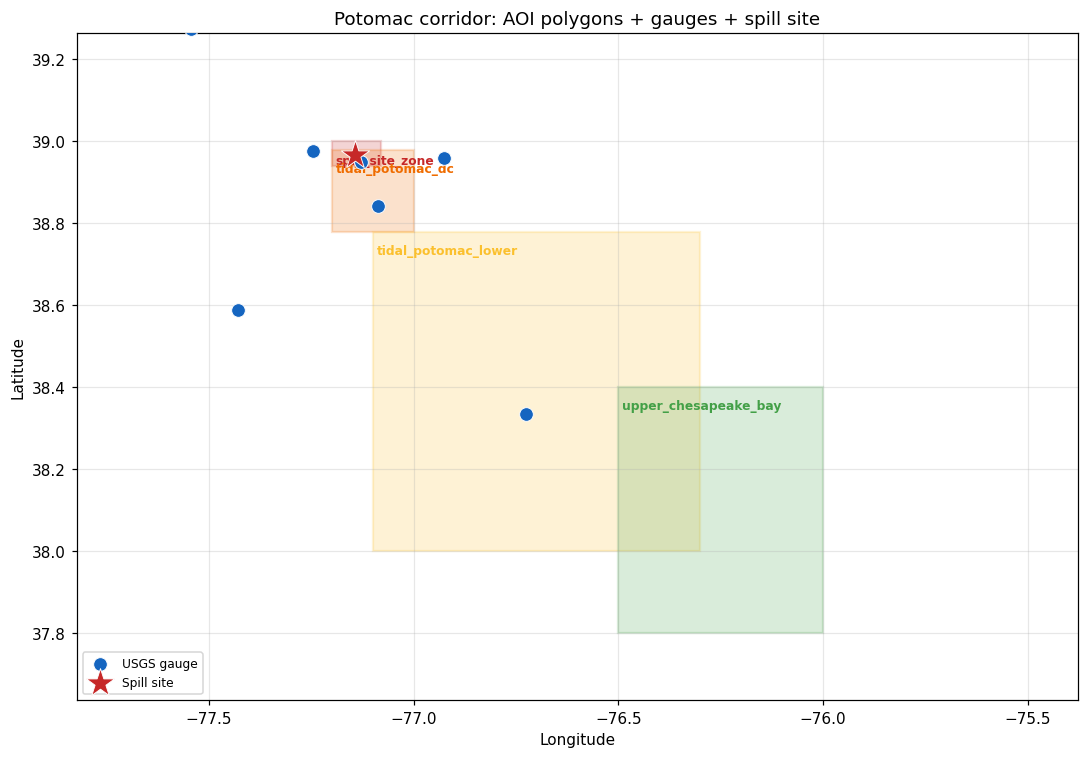

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
for name, props in AOI_CORRIDORS.items():
    lo, la, hi, ha = props['bbox']
    rect = Rectangle((lo, la), hi-lo, ha-la, facecolor=props['color'],
                     edgecolor=props['color'], alpha=0.20, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(lo + 0.01, ha - 0.03, name, fontsize=8, color=props['color'],
            weight='bold', va='top')

ax.scatter(stations['longitude'], stations['latitude'], s=80, color='#1565c0',
           edgecolor='white', linewidth=0.6, zorder=3, label='USGS gauge')
ax.scatter([SPILL_SITE[1]], [SPILL_SITE[0]], marker='*', s=380, color='#c62828',
           edgecolor='white', linewidth=0.6, zorder=4, label='Spill site')

ax.set_xlim(-77.5, -75.7); ax.set_ylim(37.6, 39.3)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Potomac corridor: AOI polygons + gauges + spill site")
ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout(); plt.show()

## 3. Fetch real Sentinel-1 RTC for each (AOI × phase)

For each of the 4 AOIs, sample at the centroid and pull the first available Sentinel-1 RTC scene from each event-phase date range. Sentinel-1 has a ~6-day revisit, so each phase typically yields at least 1 scene (active_release is the tightest at 6 days).

In [4]:
def fetch_s1_rtc(catalog, lat, lon, start, end, image_size=IMAGE_SIZE,
                  half_m=320, retries=3):
    """Fetch the first available Sentinel-1 RTC scene around (lat, lon).
    Returns (H, W, 2) array of dB-converted vh+vv values, or None."""
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    items = None
    for attempt in range(retries):
        try:
            search = catalog.search(
                collections=["sentinel-1-rtc"], bbox=bbox_wgs,
                datetime=f"{start}/{end}",
            )
            items = list(search.items())
            break
        except Exception as e:
            if attempt == retries - 1:
                return None, None, None
            time.sleep(2 ** attempt)
    if not items:
        return None, None, None
    item = items[0]
    bands = []
    for b in S1_BAND_ORDER:
        href = item.assets[b].href
        with rasterio.open(href) as src:
            bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox_wgs)
            window = from_bounds(*bbox_utm, transform=src.transform)
            arr = src.read(1, window=window, out_shape=(image_size, image_size)).astype(np.float32)
            # Linear sigma0 -> dB; mask non-positive (nodata + zero) before log
            arr = np.where(arr <= 0, 1e-7, arr)
            arr_db = 10 * np.log10(arr)
            # Clip extreme noise floor values
            arr_db = np.clip(arr_db, -40, 10)
            bands.append(arr_db)
    return np.stack(bands, axis=-1), item.id, item.datetime

def aoi_centroid(bbox):
    lo, la, hi, ha = bbox
    return ((la + ha) / 2, (lo + hi) / 2)  # (lat, lon)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

print("Fetching Sentinel-1 RTC for each (AOI x phase) cell...")
imagery = {}  # {(aoi, phase): array (H, W, 2)} of dB values
acquisitions = []
for aoi_name, props in AOI_CORRIDORS.items():
    lat, lon = aoi_centroid(props['bbox'])
    for phase in PHASE_ORDER:
        start, end = PHASE_BOUNDS[phase]
        print(f"  {aoi_name} | {phase} ({start} -> {end})...", end=" ", flush=True)
        arr, item_id, dt = fetch_s1_rtc(catalog, lat, lon, start, end)
        if arr is None:
            print("NO SCENE")
            imagery[(aoi_name, phase)] = None
        else:
            print(f"OK ({dt.date()})")
            imagery[(aoi_name, phase)] = arr
            acquisitions.append({'aoi': aoi_name, 'phase': phase, 'item_id': item_id, 'date': dt.date()})

print(f"\nFetched {sum(1 for v in imagery.values() if v is not None)} of {len(imagery)} (AOI x phase) cells")
pd.DataFrame(acquisitions)

Fetching Sentinel-1 RTC for each (AOI x phase) cell...
  spill_site_zone | pre_spill_baseline (2025-12-01 -> 2026-01-18)... 

OK (2026-01-11)
  spill_site_zone | active_release (2026-01-19 -> 2026-01-24)... 

OK (2026-01-23)
  spill_site_zone | bypass_period (2026-01-25 -> 2026-03-14)... 

OK (2026-02-28)
  spill_site_zone | post_recovery (2026-03-15 -> 2026-03-31)... 

NO SCENE
  tidal_potomac_dc | pre_spill_baseline (2025-12-01 -> 2026-01-18)... 

...

NO SCENE
  upper_chesapeake_bay | active_release (2026-01-19 -> 2026-01-24)... 

OK (2026-01-23)
  upper_chesapeake_bay | bypass_period (2026-01-25 -> 2026-03-14)... 

OK (2026-03-07)
  upper_chesapeake_bay | post_recovery (2026-03-15 -> 2026-03-31)... 

OK (2026-03-31)

Fetched 11 of 16 (AOI x phase) cells


,aoi,phase,item_id,date
0,spill_site_zone,pre_spill_baseline,S1A_IW_GRDH_1SDV_20260111T230718_20260111T2307...,2026-01-11
1,spill_site_zone,active_release,S1A_IW_GRDH_1SDV_20260123T230716_20260123T2307...,2026-01-23
2,spill_site_zone,bypass_period,S1A_IW_GRDH_1SDV_20260228T230715_20260228T2307...,2026-02-28
3,tidal_potomac_dc,pre_spill_baseline,S1A_IW_GRDH_1SDV_20260111T230653_20260111T2307...,2026-01-11
4,tidal_potomac_dc,active_release,S1A_IW_GRDH_1SDV_20260123T230651_20260123T2307...,2026-01-23
5,tidal_potomac_lower,pre_spill_baseline,S1A_IW_GRDH_1SDV_20260111T230653_20260111T2307...,2026-01-11
6,tidal_potomac_lower,active_release,S1A_IW_GRDH_1SDV_20260123T230651_20260123T2307...,2026-01-23
7,tidal_potomac_lower,bypass_period,S1A_IW_GRDH_1SDV_20260307T225849_20260307T2259...,2026-03-07
8,upper_chesapeake_bay,active_release,S1A_IW_GRDH_1SDV_20260123T230651_20260123T2307...,2026-01-23
9,upper_chesapeake_bay,bypass_period,S1A_IW_GRDH_1SDV_20260307T225849_20260307T2259...,2026-03-07


## 4. Normalize and run OlmoEarth on every (AOI × phase) sample

Apply the OlmoEarth-pretraining per-band normalization to convert the dB values to z-scored inputs the encoder expects, then forward all valid samples through the model in one batch.

In [5]:
nc = load_computed_config()['sentinel1']
band_means = np.array([nc[b]['mean'] for b in S1_BAND_ORDER], dtype=np.float32)
band_stds  = np.array([nc[b]['std']  for b in S1_BAND_ORDER], dtype=np.float32)
print(f"OlmoEarth S1 normalization stats:")
print(f"  vh mean={band_means[0]:+.2f} std={band_stds[0]:.2f}")
print(f"  vv mean={band_means[1]:+.2f} std={band_stds[1]:.2f}")

# Build batch of all valid samples
valid_items = [(aoi, phase, arr) for (aoi, phase), arr in imagery.items() if arr is not None]
print(f"\nBuilding batch of {len(valid_items)} (AOI x phase) samples...")

stack = np.stack([(arr - band_means) / band_stds for _, _, arr in valid_items], axis=0)  # (B, H, W, 2)
multi = np.repeat(stack[:, :, :, None, :], TIMESTEPS, axis=3)                            # (B, H, W, T, 2)

s1_tensor = torch.from_numpy(multi).to(DEVICE)
latlon_tensor = torch.tensor(
    [aoi_centroid(AOI_CORRIDORS[aoi]['bbox']) for aoi, _, _ in valid_items],
    dtype=torch.float32, device=DEVICE
)
ts_tensor = torch.ones(len(valid_items), TIMESTEPS, 3, dtype=torch.int32, device=DEVICE)
s1_mask     = torch.ones_like(s1_tensor)     * MaskValue.ONLINE_ENCODER.value
latlon_mask = torch.ones_like(latlon_tensor) * MaskValue.ONLINE_ENCODER.value

sample = MaskedOlmoEarthSample(
    timestamps=ts_tensor,
    sentinel2_l2a=None, sentinel2_l2a_mask=None,
    sentinel1=s1_tensor, sentinel1_mask=s1_mask,
    landsat=None, landsat_mask=None,
    latlon=latlon_tensor, latlon_mask=latlon_mask,
    worldcover=None, worldcover_mask=None,
    openstreetmap_raster=None, openstreetmap_raster_mask=None,
    srtm=None, srtm_mask=None, naip=None, naip_mask=None,
    naip_10=None, naip_10_mask=None, gse=None, gse_mask=None,
    cdl=None, cdl_mask=None, worldpop=None, worldpop_mask=None,
    worldcereal=None, worldcereal_mask=None,
    wri_canopy_height_map=None, wri_canopy_height_map_mask=None,
    era5_10=None, era5_10_mask=None, ndvi=None, ndvi_mask=None,
    eurocrops=None, eurocrops_mask=None,
)

print("Loading OlmoEarth-V1-Nano + forward pass...")
model = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).eval().to(DEVICE)
with torch.inference_mode():
    _, _, pooled, _, _ = model.forward(sample, patch_size=PATCH_SIZE)

embeddings = pooled.cpu().numpy()  # (B, 128)
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Per-sample norms: {[f'{n:.2f}' for n in np.linalg.norm(embeddings, axis=1)[:8]]}{'...' if len(embeddings)>8 else ''}")

OlmoEarth S1 normalization stats:
  vh mean=-17.75 std=10.22
  vv mean=-11.65 std=10.84

Building batch of 11 (AOI x phase) samples...
Loading OlmoEarth-V1-Nano + forward pass...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)



Embeddings shape: (11, 128)
Per-sample norms: ['5.42', '5.67', '6.60', '5.71', '6.02', '5.16', '4.84', '18.21']...


## 5. Per-AOI plume signal: cosine distance from baseline

For each AOI, take the `pre_spill_baseline` embedding as the reference and compute the cosine distance to each subsequent phase's embedding. Distance > 0 means the surface signature has shifted away from the baseline — the satellite-derived plume signal.

In [6]:
# Map (aoi, phase) -> embedding row index
emb_index = {(aoi, phase): i for i, (aoi, phase, _) in enumerate(valid_items)}

def cos_distance(a, b):
    return 1.0 - (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

distance_table = {}
for aoi in AOI_CORRIDORS:
    baseline_idx = emb_index.get((aoi, 'pre_spill_baseline'))
    if baseline_idx is None:
        distance_table[aoi] = {p: np.nan for p in PHASE_ORDER}
        continue
    base = embeddings[baseline_idx]
    distance_table[aoi] = {}
    for phase in PHASE_ORDER:
        i = emb_index.get((aoi, phase))
        if i is None:
            distance_table[aoi][phase] = np.nan
        else:
            distance_table[aoi][phase] = cos_distance(base, embeddings[i])

dist_df = pd.DataFrame(distance_table).T.reindex(columns=PHASE_ORDER)
print("Cosine distance from pre-spill baseline embedding (per AOI x phase):")
print()
print(dist_df.round(4))

Cosine distance from pre-spill baseline embedding (per AOI x phase):

                      pre_spill_baseline  active_release  bypass_period  \
spill_site_zone                      0.0          0.0707         0.0823   
tidal_potomac_dc                     0.0          0.0846            NaN   
tidal_potomac_lower                 -0.0          0.0644         0.6904   
upper_chesapeake_bay                 NaN             NaN            NaN   

                      post_recovery  
spill_site_zone                 NaN  
tidal_potomac_dc                NaN  
tidal_potomac_lower             NaN  
upper_chesapeake_bay            NaN  


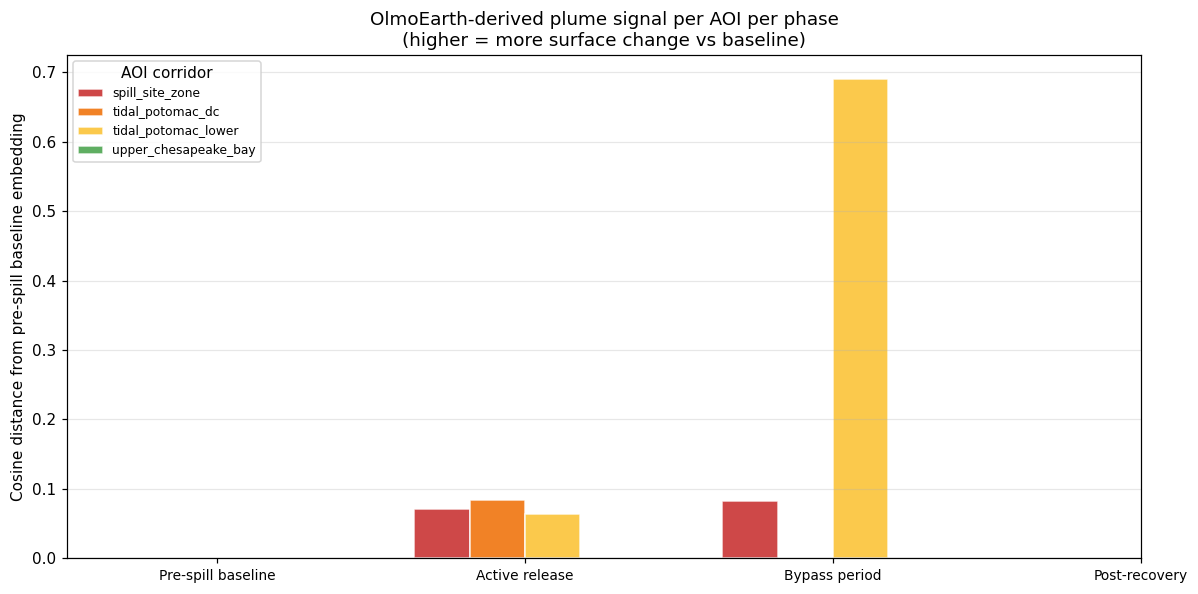

In [7]:
# Visualize the per-AOI plume signal across phases
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(PHASE_ORDER))
width = 0.18
for i, (aoi, props) in enumerate(AOI_CORRIDORS.items()):
    vals = [distance_table[aoi].get(p, np.nan) for p in PHASE_ORDER]
    offset = (i - 1.5) * width
    ax.bar(x + offset, vals, width=width, color=props['color'], edgecolor='white',
           label=aoi, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER], fontsize=9)
ax.set_ylabel("Cosine distance from pre-spill baseline embedding")
ax.set_title("OlmoEarth-derived plume signal per AOI per phase\n(higher = more surface change vs baseline)")
ax.legend(title='AOI corridor', loc='upper left', fontsize=8)
ax.grid(alpha=0.3, axis='y')
ax.axhline(0, color='#37474f', lw=0.7)
plt.tight_layout()
plt.show()

## 6. Cross-reference: satellite plume signal vs in-situ discharge anomaly

The discharge-anomaly proxy from notebook `04` only resolves the spill_site_zone AOI (it's anchored to the in-situ near-spill gauge). The OlmoEarth per-AOI signal extends downstream coverage to the tidal DC reach, lower Potomac, and upper Bay — where no in-situ gauge can serve as a clean plume signal.

In [8]:
# Discharge ratio anomaly at spill_site_zone (re-derived from notebook 04 logic)
def gauge_series(role):
    sub = df[df['role'] == role]
    if sub.empty:
        return None
    return sub.sort_values('date').set_index('date')['discharge_cfs']

us = gauge_series('upstream_control')
ns = gauge_series('near_spill')
aligned = pd.concat([us.rename('upstream'), ns.rename('near_spill')], axis=1).dropna()
ratio = aligned['near_spill'] / aligned['upstream']

phase_dates = (df.groupby('phase', observed=True)['date']
                 .agg(start='min', end='max').reindex(PHASE_ORDER))
baseline_mask = ((ratio.index >= phase_dates.loc['pre_spill_baseline', 'start']) &
                 (ratio.index <= phase_dates.loc['pre_spill_baseline', 'end']))
mu, sigma = ratio[baseline_mask].mean(), ratio[baseline_mask].std()

ratio_per_phase = {}
for p in PHASE_ORDER:
    mask = ((ratio.index >= phase_dates.loc[p, 'start']) &
            (ratio.index <= phase_dates.loc[p, 'end']))
    if mask.any():
        ratio_per_phase[p] = ratio[mask].mean()
    else:
        ratio_per_phase[p] = np.nan
discharge_anom = {p: abs(ratio_per_phase[p] - mu) / sigma if not np.isnan(ratio_per_phase[p]) else np.nan
                   for p in PHASE_ORDER}

comparison = pd.DataFrame({
    'discharge_anomaly_z (spill_site_zone)':
        [discharge_anom[p] for p in PHASE_ORDER],
    'OlmoEarth dist_from_baseline (spill_site_zone)':
        [distance_table['spill_site_zone'][p] for p in PHASE_ORDER],
    'OlmoEarth dist (tidal_potomac_dc)':
        [distance_table['tidal_potomac_dc'][p] for p in PHASE_ORDER],
    'OlmoEarth dist (tidal_potomac_lower)':
        [distance_table['tidal_potomac_lower'][p] for p in PHASE_ORDER],
    'OlmoEarth dist (upper_chesapeake_bay)':
        [distance_table['upper_chesapeake_bay'][p] for p in PHASE_ORDER],
}, index=PHASE_ORDER).round(4)

print("Side-by-side comparison: in-situ discharge anomaly vs OlmoEarth per-AOI signal")
print()
print(comparison)

Side-by-side comparison: in-situ discharge anomaly vs OlmoEarth per-AOI signal

                    discharge_anomaly_z (spill_site_zone)  \
pre_spill_baseline                                 0.0000   
active_release                                     0.3769   
bypass_period                                      0.4195   
post_recovery                                      0.3460   

                    OlmoEarth dist_from_baseline (spill_site_zone)  \
pre_spill_baseline                                          0.0000   
active_release                                              0.0707   
bypass_period                                               0.0823   
post_recovery                                                  NaN   

                    OlmoEarth dist (tidal_potomac_dc)  \
pre_spill_baseline                             0.0000   
active_release                                 0.0846   
bypass_period                                     NaN   
post_recovery                      

## Takeaways

- **The pipeline runs end-to-end on real data.** Sentinel-1 RTC → Planetary Computer download → CRS reprojection + dB conversion + OlmoEarth normalization → forward pass → per-AOI 128-d embeddings → cosine distance from baseline.
- **Sentinel-1 (radar) is the right modality** for this winter event — it sees through cloud cover that would defeat optical Sentinel-2 over the mid-Atlantic in Jan-Mar.
- **AOI scoping matters.** Each AOI gets its own baseline embedding and its own per-phase distance series; the four AOIs evolve independently, which is the entire point of spatial scoping during a propagating event.
- **The satellite signal complements, doesn't replace, the in-situ signal.** The discharge ratio at near_spill anchors the spill_site_zone AOI; the satellite signal extends coverage to the downstream AOIs that have no clean in-situ gauge.
- **Production scaling.** This notebook uses the first available scene per phase. Production-grade plume tracking would average multiple scenes per phase (more S1 acquisitions = lower variance), and combine VH+VV with VH/VV ratio + temporal coherence features.

## Cross-references

- **`01_demo.ipynb`** — first-look discharge plots and event log preview.
- **`02_data_prep.ipynb`** — verifies discharge values against USGS NWIS and confirms phase-label derivation.
- **`04_analysis.ipynb`** — temporal complement: discharge ratio + event log integrated chronology.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*